In [61]:
from ctypes import kind

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

ImportError: cannot import name 'kind' from 'ctypes' (C:\Program Files\Python314\Lib\ctypes\__init__.py)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [ ]:
df = pd.read_csv('concrete_data.csv')

In [ ]:
df.head(5)

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [ ]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [ ]:
# Applying Regression without any transformation

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

In [ ]:
# Cross-checking with cross val score

lr = LinearRegression()
np.mean(cross_val_score(lr, X, y, scoring='r2'))

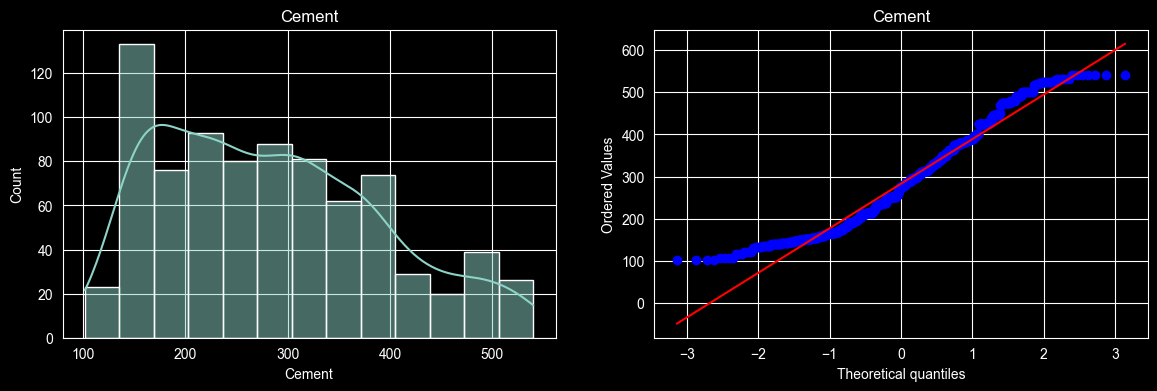

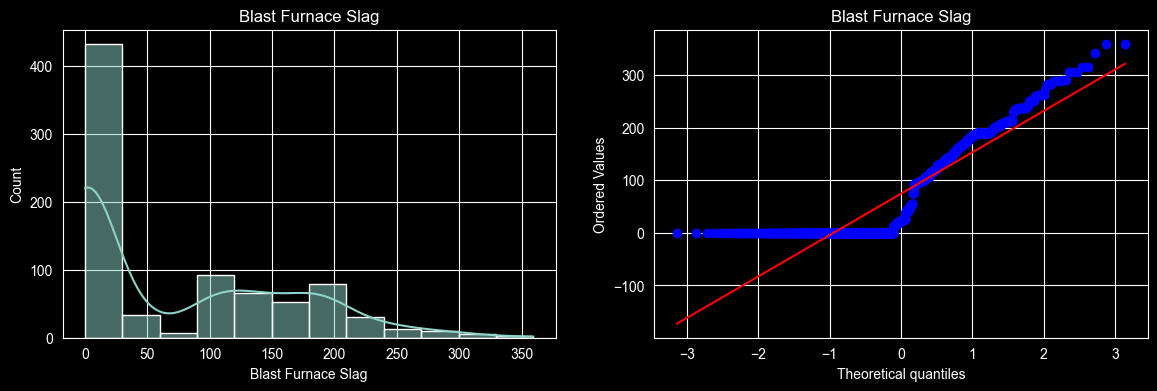

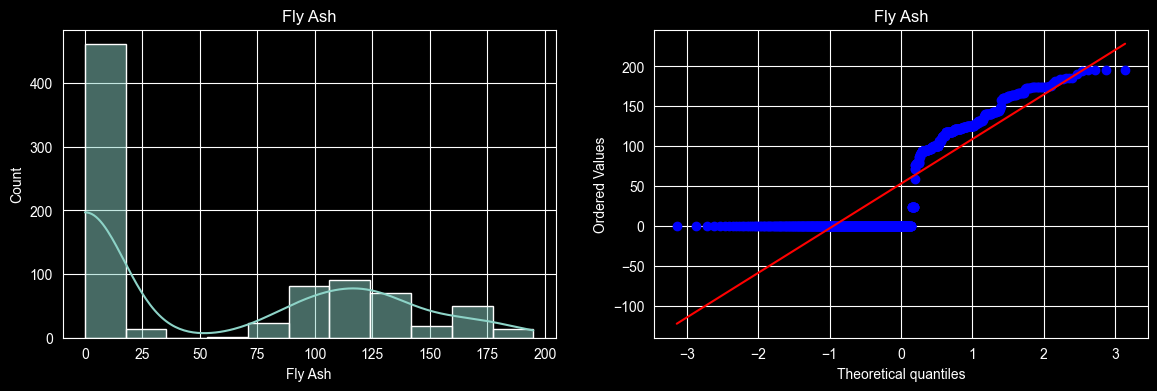

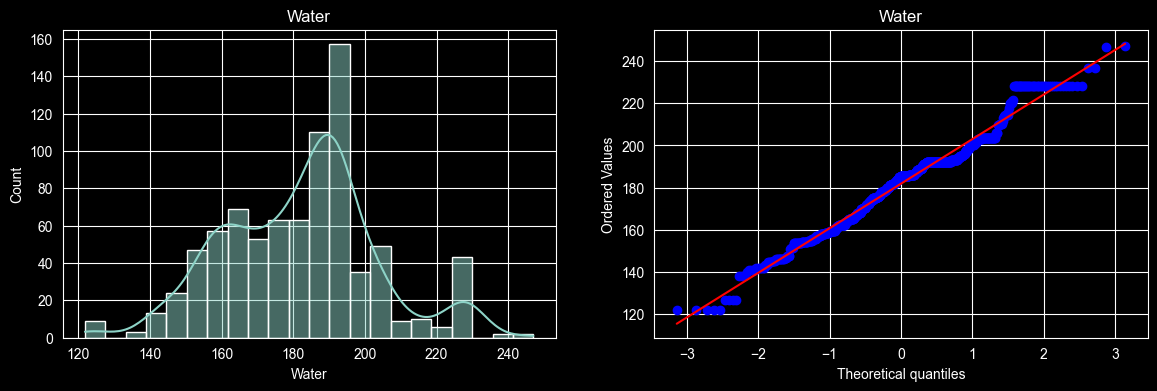

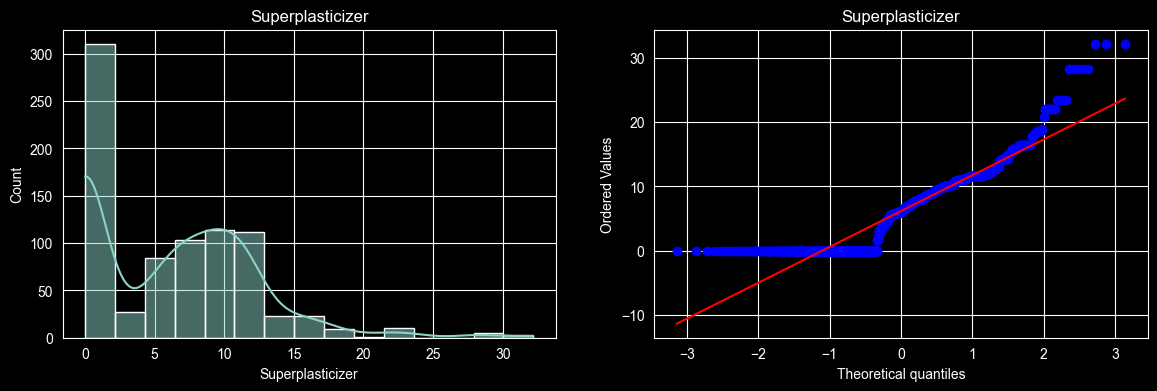

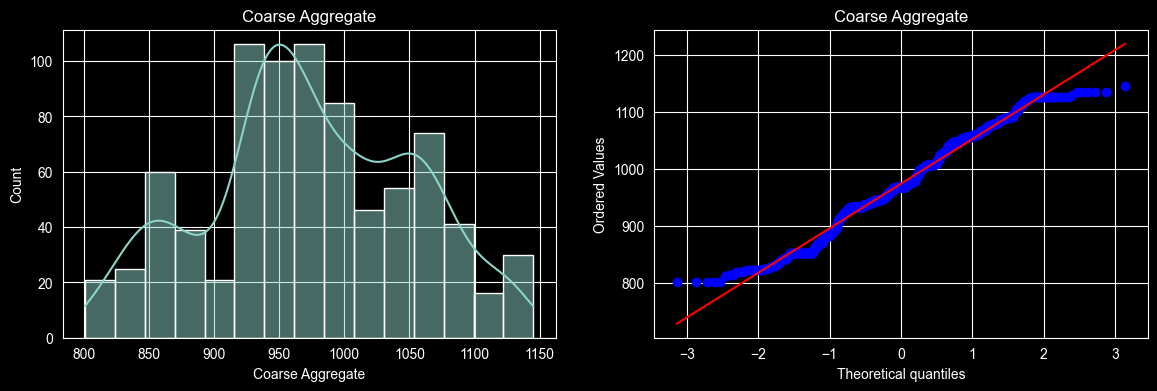

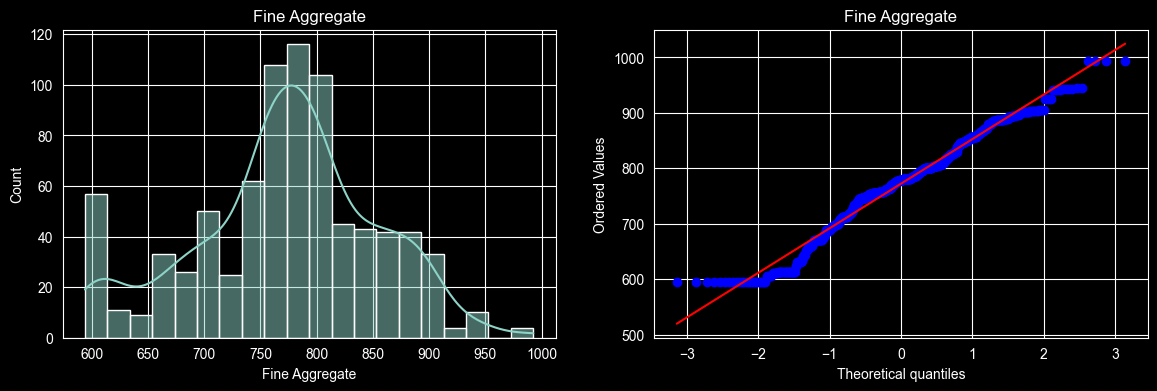

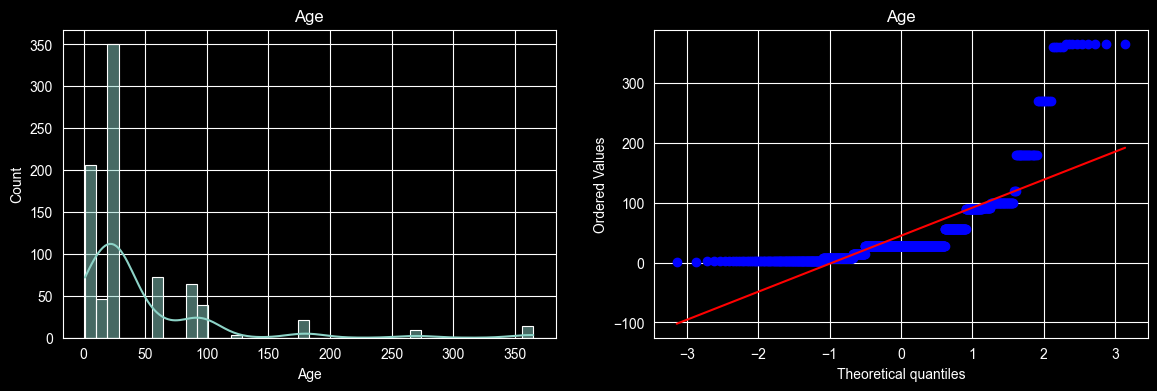

In [62]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist = 'norm', plot = plt)
    plt.title(col)

    plt.show()

In [63]:
# Apply Box-cox transformer

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols': X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [64]:
# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test, y_pred2)

0.8047825008078887

In [65]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.000001)

lr = LinearRegression()
np.mean(cross_val_score(lr, X_transformed, y, scoring='r2'))

np.float64(0.6662950326831087)

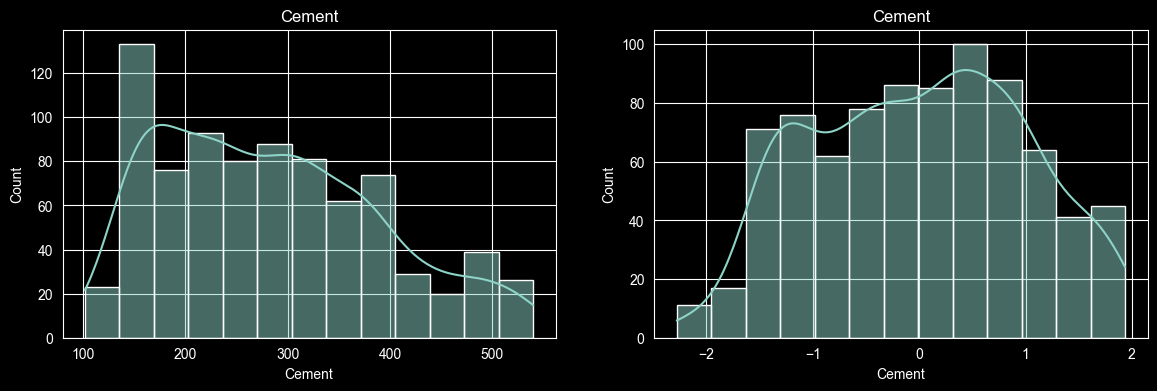

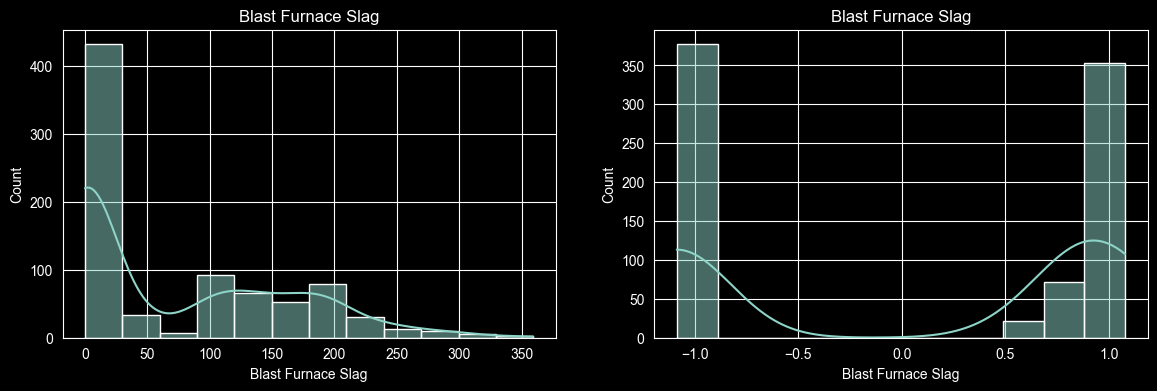

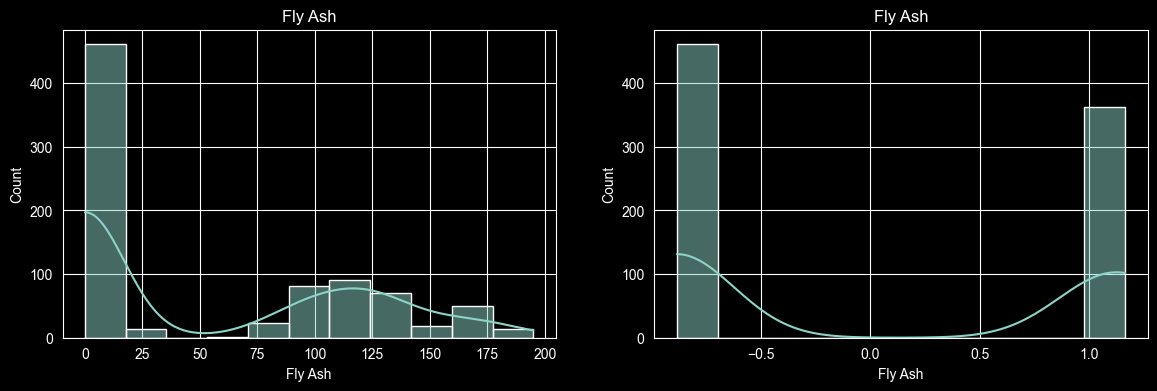

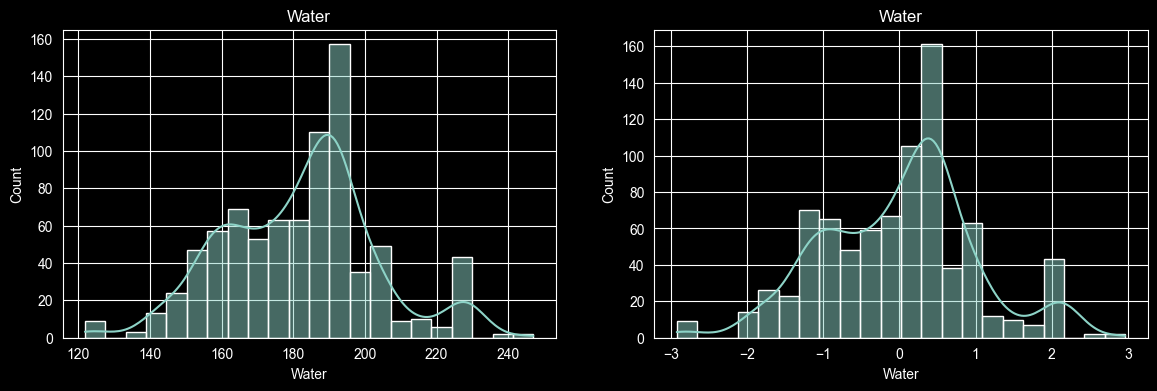

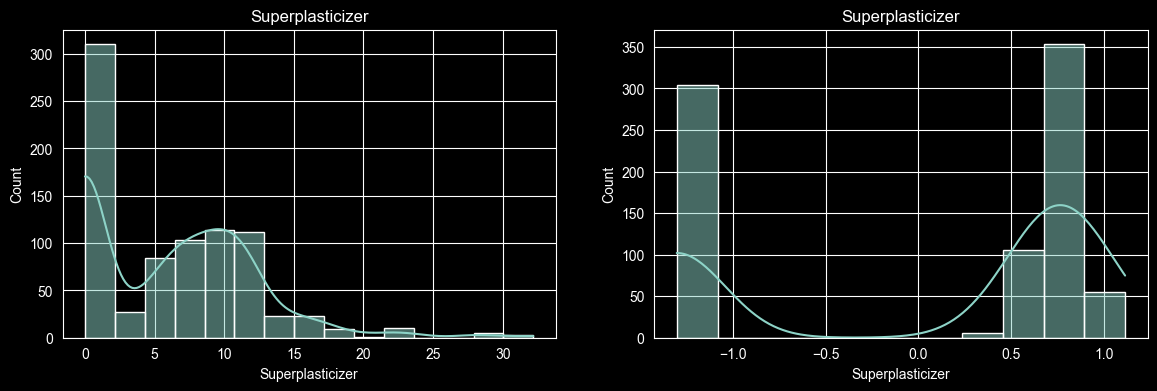

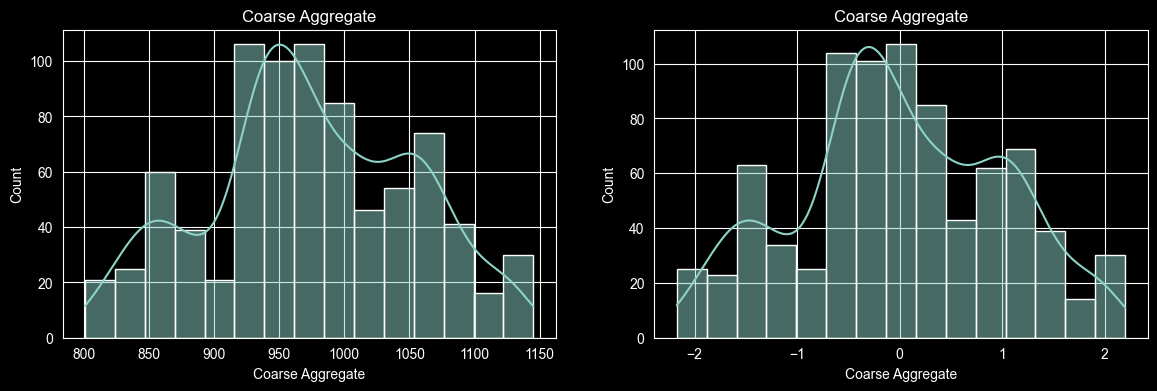

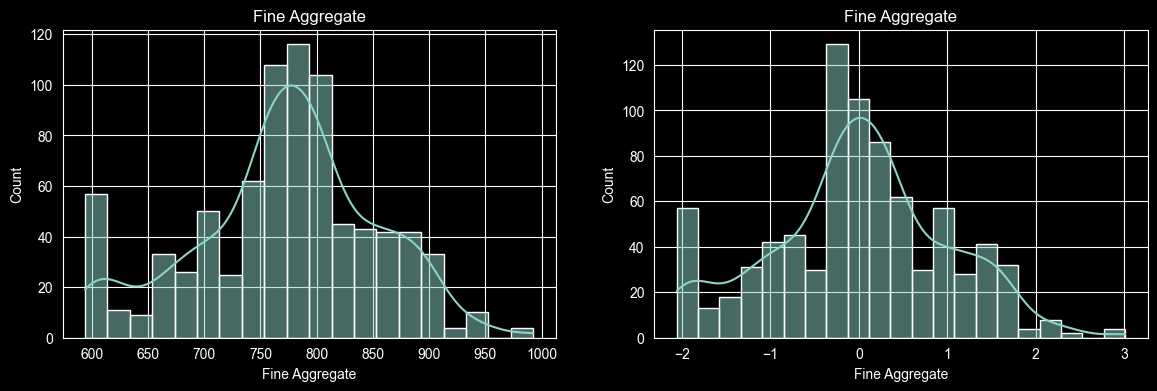

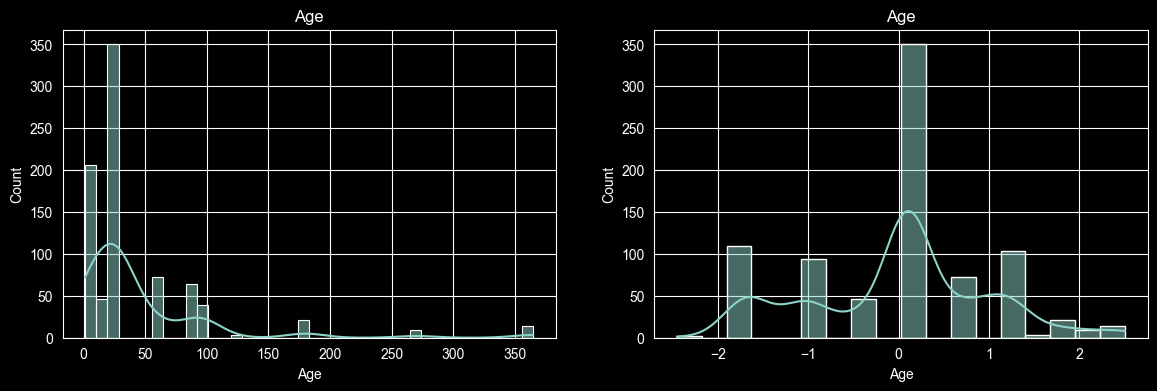

In [66]:
# Before and after comparison for Box-cox plot

X_train_transformed = pd.DataFrame(X_train_transformed,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(col)

    plt.show()

In [67]:
# Apply yeo-johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2, y_train)

y_pred3 = lr.predict(X_test_transformed2)
print(r2_score(y_test, y_pred3))

pd.DataFrame({'cols': X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8161906511066099


,cols,Yeo_Johnson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [68]:
# Apply cross val score
pt = PowerTransformer()
X_transformed2 = pt.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr, X_transformed2, y, scoring='r2'))

np.float64(0.6834625126992434)

In [69]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2, columns=X_train.columns)

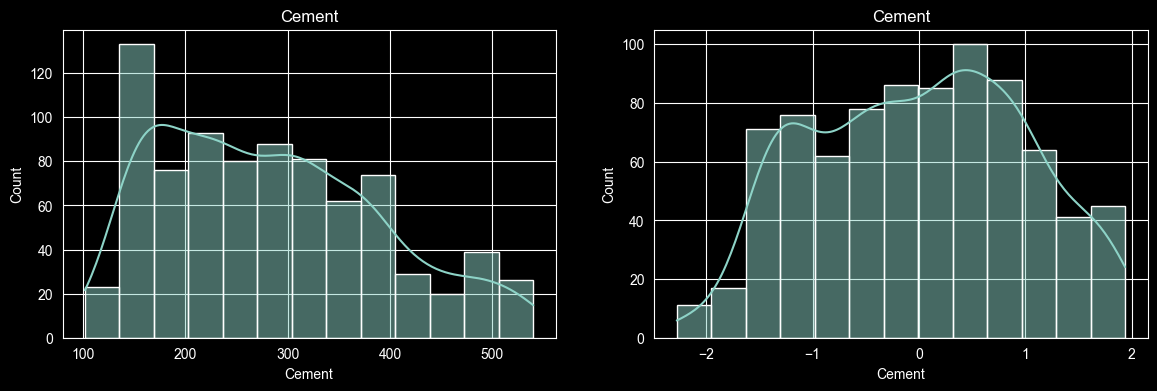

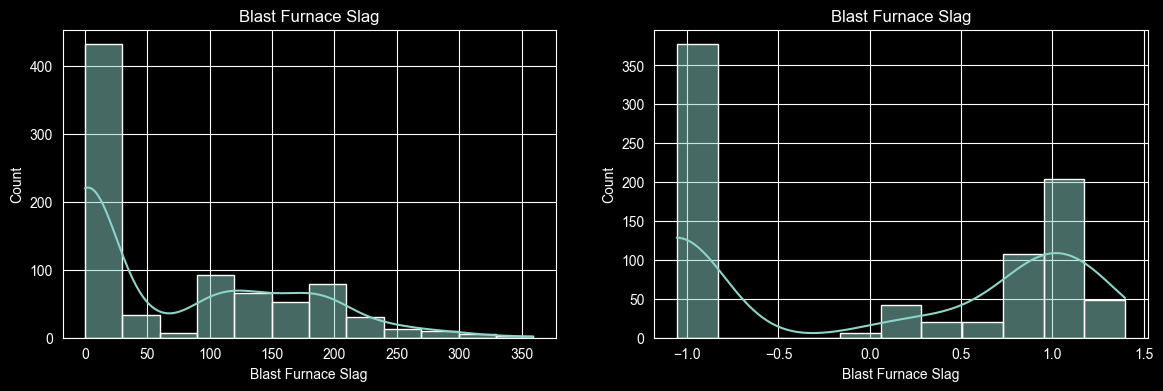

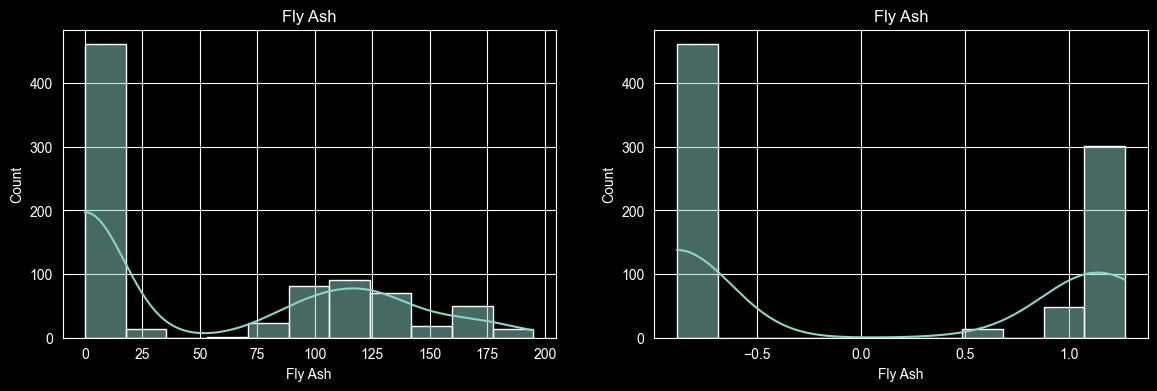

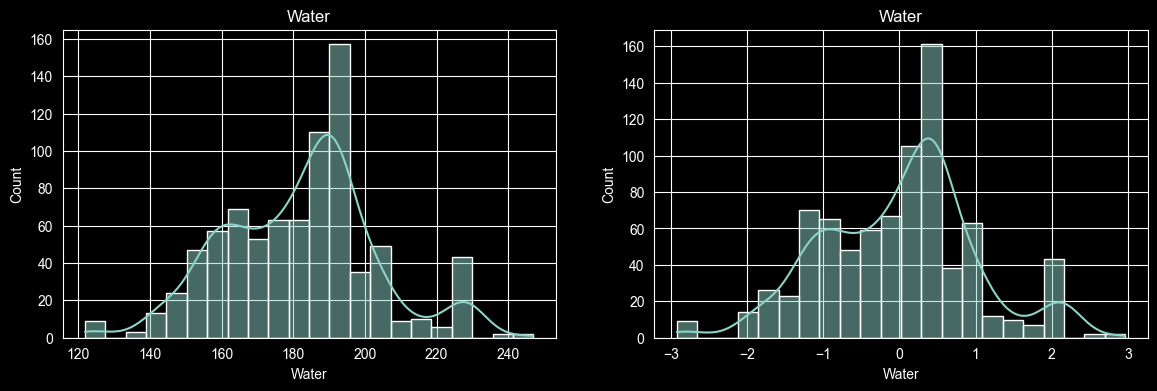

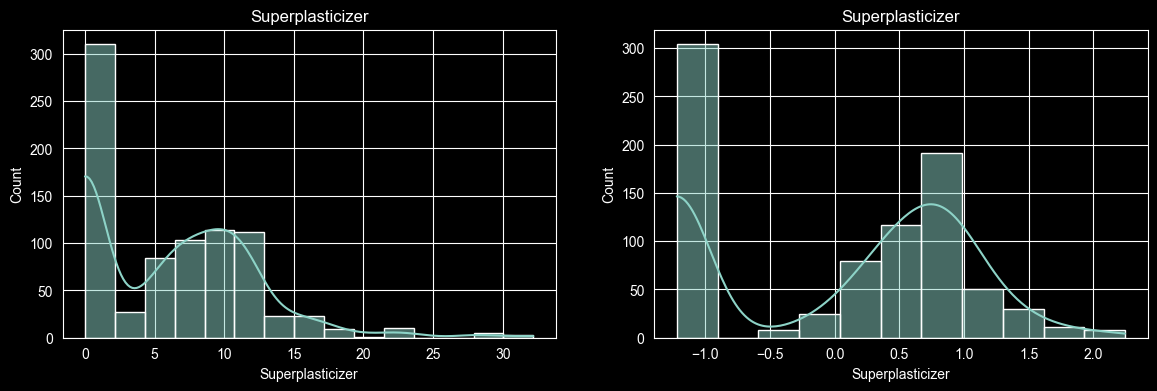

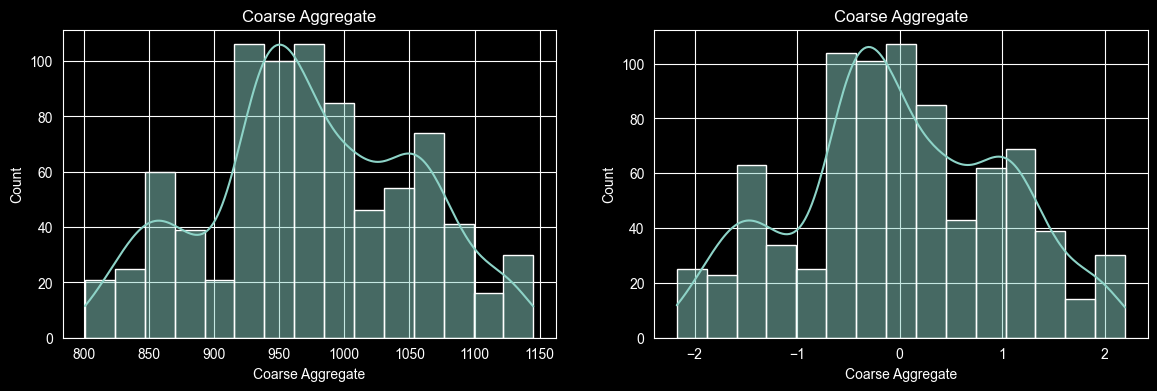

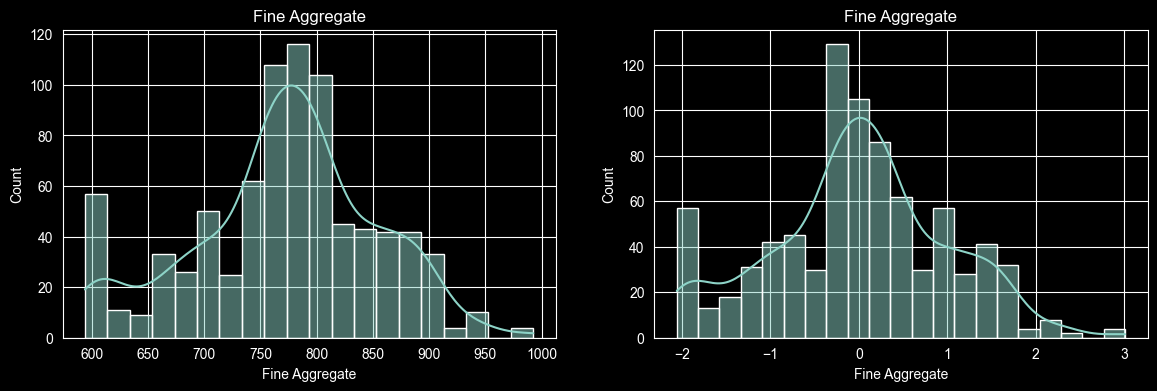

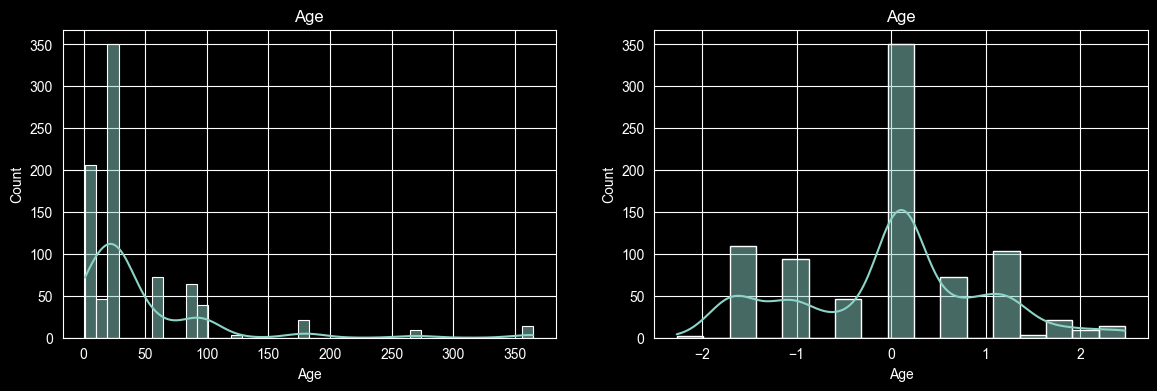

In [70]:
# Before and after comparison for Yeo-Johnson

for col in X_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col], kde = True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(X_train_transformed2[col], kde = True)
    plt.title(col)

    plt.show()

In [71]:
# Side by side lambdas
pd.DataFrame({'cols': X_train.columns, 'box_cox_lambdas': pt1.lambdas_, 'Yeo_Johnson_lambdas': pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.174348,0.174348
1,Blast Furnace Slag,0.015715,0.015715
2,Fly Ash,-0.161447,-0.161447
3,Water,0.771307,0.771307
4,Superplasticizer,0.253935,0.253935
5,Coarse Aggregate,1.130050,1.130050
6,Fine Aggregate,1.783100,1.783100
7,Age,0.019885,0.019885
